In [1]:
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import pandas as pd
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

Downloading the data.

In [2]:
tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "META"]

In [3]:
# end_date = datetime(year=2026, month=4, day=1)
# start_date = datetime(year=2010, month=1, day=1)

# yf.set_tz_cache_location("temp_cache")

# data = yf.download(tickers, start="2010-01-01", end="2026-04-01", interval="1d")

# data.to_csv("stocks_data.csv")

Loading the data.

In [4]:
data = pd.read_csv("stocks_data.csv", header=[0, 1], index_col=0, parse_dates=True)

print(data['Close'].head())

Ticker          AAPL    AMZN      GOOGL  META       MSFT
Date                                                    
2010-01-04  6.412383  6.6950  15.555864   NaN  23.077381
2010-01-05  6.423469  6.7345  15.487362   NaN  23.084829
2010-01-06  6.321297  6.6125  15.096945   NaN  22.943165
2010-01-07  6.309610  6.5000  14.745497   NaN  22.704571
2010-01-08  6.351558  6.6760  14.942070   NaN  22.861153


Splitting the data.

In [5]:
n = len(data)

train_df = data[0 : int(n*0.7)]
val_df   = data[int(n*0.7) : int(n*0.85)]
test_df  = data[int(n*0.85) : ]

In [6]:
print(f"Train size: {len(train_df)}")
print(f"Val size:   {len(val_df)}")
print(f"Test size:  {len(test_df)}")

Train size: 2859
Val size:   613
Test size:  613


In [7]:
train_df.isnull().sum()

Price   Ticker
Close   AAPL        0
        AMZN        0
        GOOGL       0
        META      599
        MSFT        0
High    AAPL        0
        AMZN        0
        GOOGL       0
        META      599
        MSFT        0
Low     AAPL        0
        AMZN        0
        GOOGL       0
        META      599
        MSFT        0
Open    AAPL        0
        AMZN        0
        GOOGL       0
        META      599
        MSFT        0
Volume  AAPL        0
        AMZN        0
        GOOGL       0
        META      599
        MSFT        0
dtype: int64

In [8]:
print(train_df['High']['META'].head(600))

Date
2010-01-04          NaN
2010-01-05          NaN
2010-01-06          NaN
2010-01-07          NaN
2010-01-08          NaN
                ...    
2012-05-14          NaN
2012-05-15          NaN
2012-05-16          NaN
2012-05-17          NaN
2012-05-18    44.649619
Name: META, Length: 600, dtype: float64


In [9]:
train_df.index = pd.to_datetime(train_df.index)
early_dates = train_df.index < "2012-05-18"
idx = pd.IndexSlice
train_df.loc[early_dates, idx[:, 'META']] = np.nan
train_df.head()

Price          Close                                         High          \
Ticker          AAPL    AMZN      GOOGL META       MSFT      AAPL    AMZN   
Date                                                                        
2010-01-04  6.412383  6.6950  15.555864  NaN  23.077381  6.427064  6.8305   
2010-01-05  6.423469  6.7345  15.487362  NaN  23.084829  6.459724  6.7740   
2010-01-06  6.321297  6.6125  15.096945  NaN  22.943165  6.448939  6.7365   
2010-01-07  6.309610  6.5000  14.745497  NaN  22.704571  6.352158  6.6160   
2010-01-08  6.351558  6.6760  14.942070  NaN  22.861153  6.352157  6.6840   

Price                                  ...      Open                          \
Ticker          GOOGL META       MSFT  ...      AAPL    AMZN      GOOGL META   
Date                                   ...                                     
2010-01-04  15.624368  NaN  23.189226  ...  6.395004  6.8125  15.560828  NaN   
2010-01-05  15.582919  NaN  23.189219  ...  6.430061  6.6715  15.566538  NaN   
2010-01-06  15.533775  NaN  23.174311  ...  6.423470  6.7300  15.533775  NaN   
2010-01-07  15.140134  NaN  22.890979  ...  6.344667  6.6005  15.125241  NaN   
2010-01-08  14.972598  NaN  23.025192  ...  6.301220  6.5280  14.693374  NaN   

Price                     Volume                                       
Ticker           MSFT       AAPL       AMZN      GOOGL META      MSFT  
Date                                                                   
2010-01-04  22.831322  493729600  151998000   78169752  NaN  38409100  
2010-01-05  23.002811  601904800  177038000  120067812  NaN  49749600  
2010-01-06  23.025184  552160000  143576000  158988852  NaN  58182400  
2010-01-07  22.838784  477131200  220604000  256315428  NaN  50559700  
2010-01-08  22.577812  447610800  196610000  188783028  NaN  51197400  

[5 rows x 25 columns]

Plotting High Stock Prices

Since the 'High'column is of continuous data type we will use line graph to visualize it.

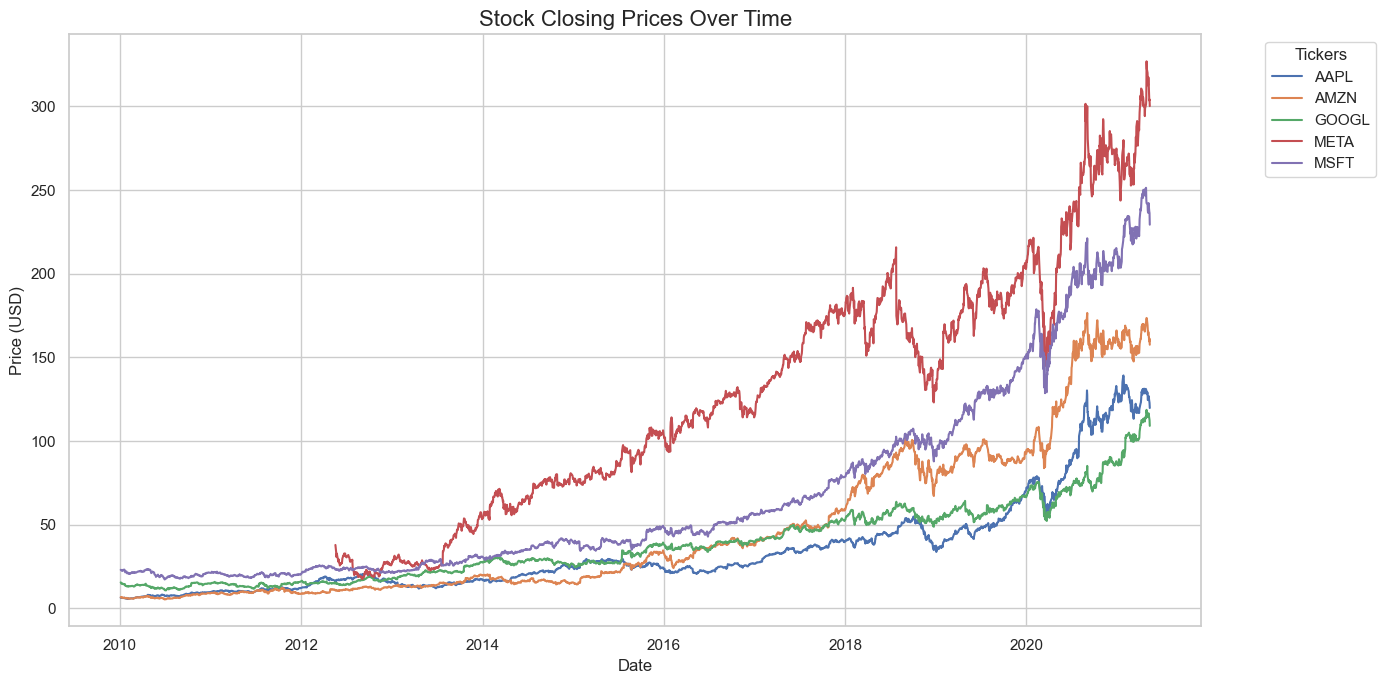

In [10]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(14, 7))

sns.lineplot(data=train_df['Close'], dashes=False)

plt.title('Stock Closing Prices Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(title='Tickers', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
plt.show()

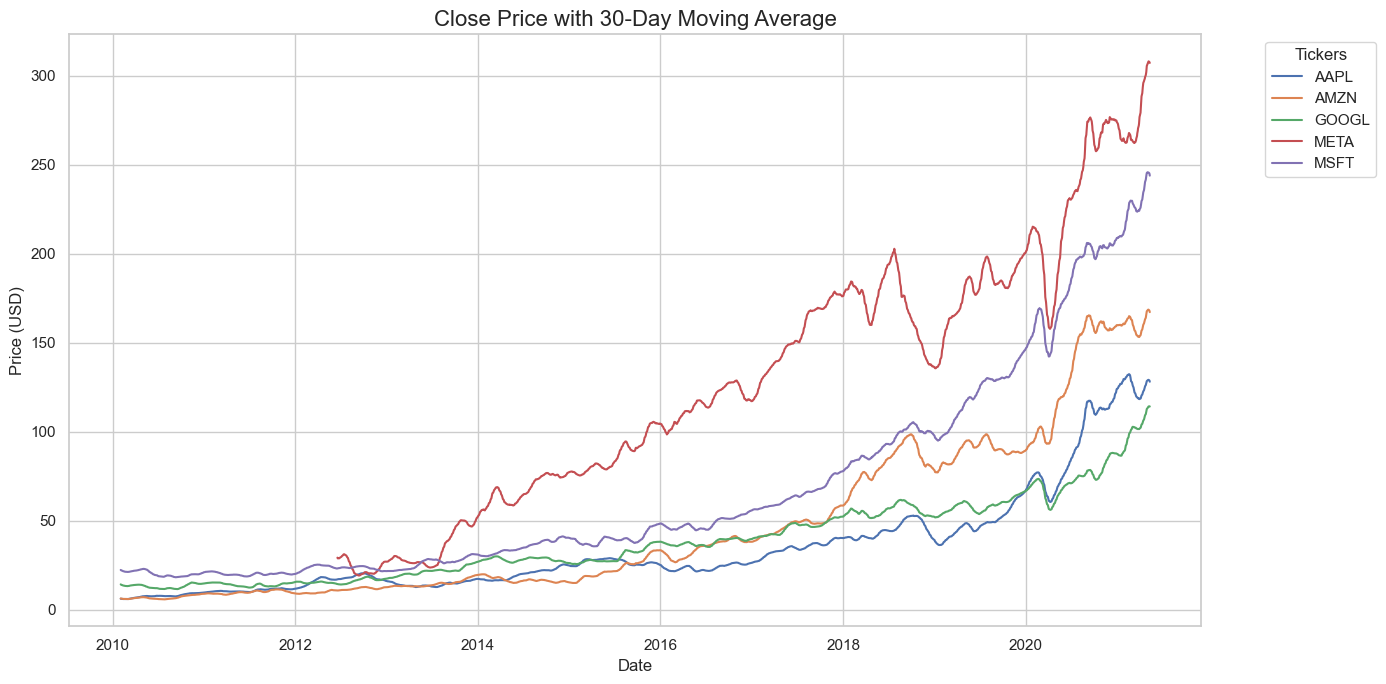

In [11]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(14, 7))

sns.lineplot(data=train_df['Close'].rolling(window=21).mean(), dashes=False)

plt.title('Close Price with 30-Day Moving Average', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.legend(title='Tickers', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
plt.show()

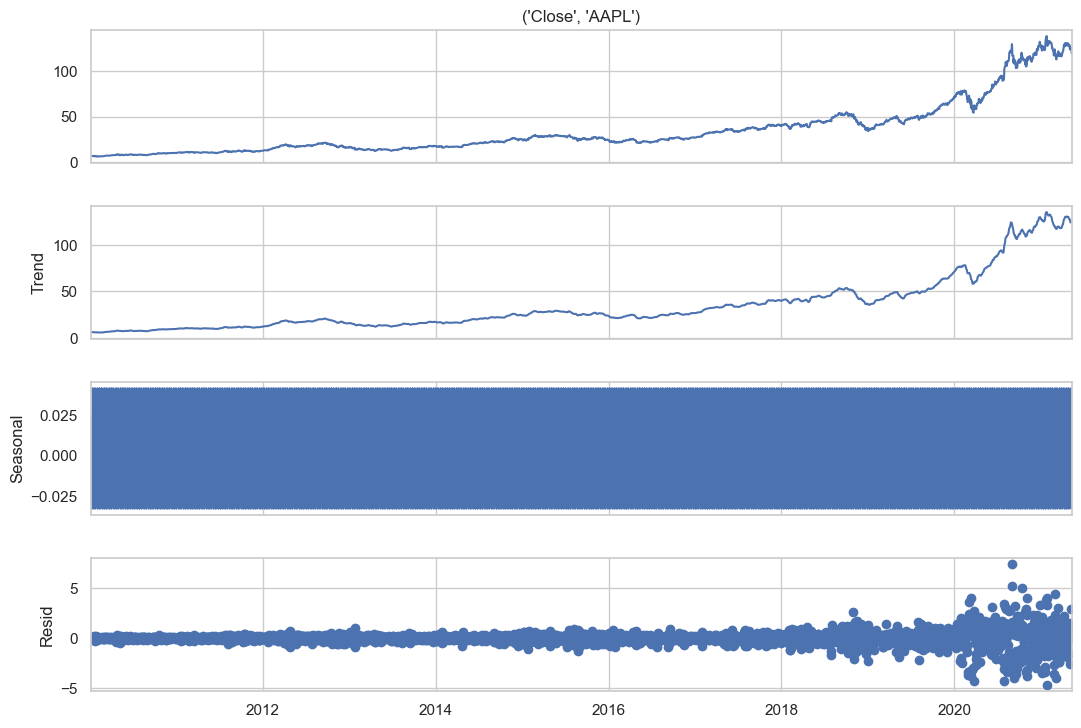

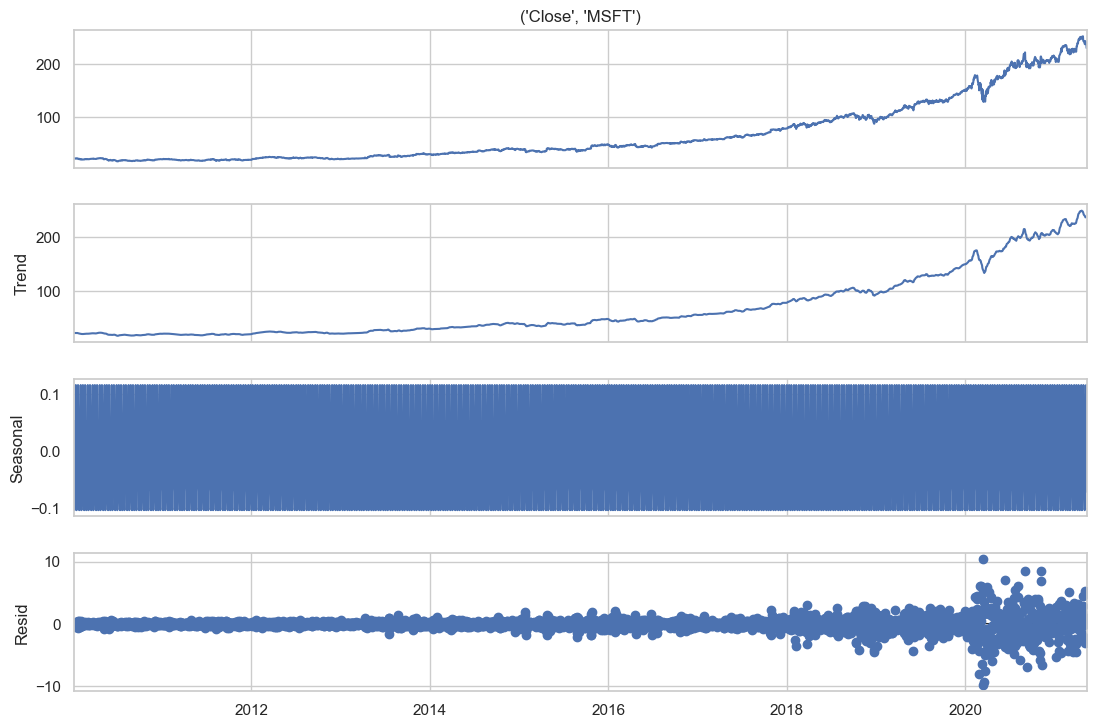

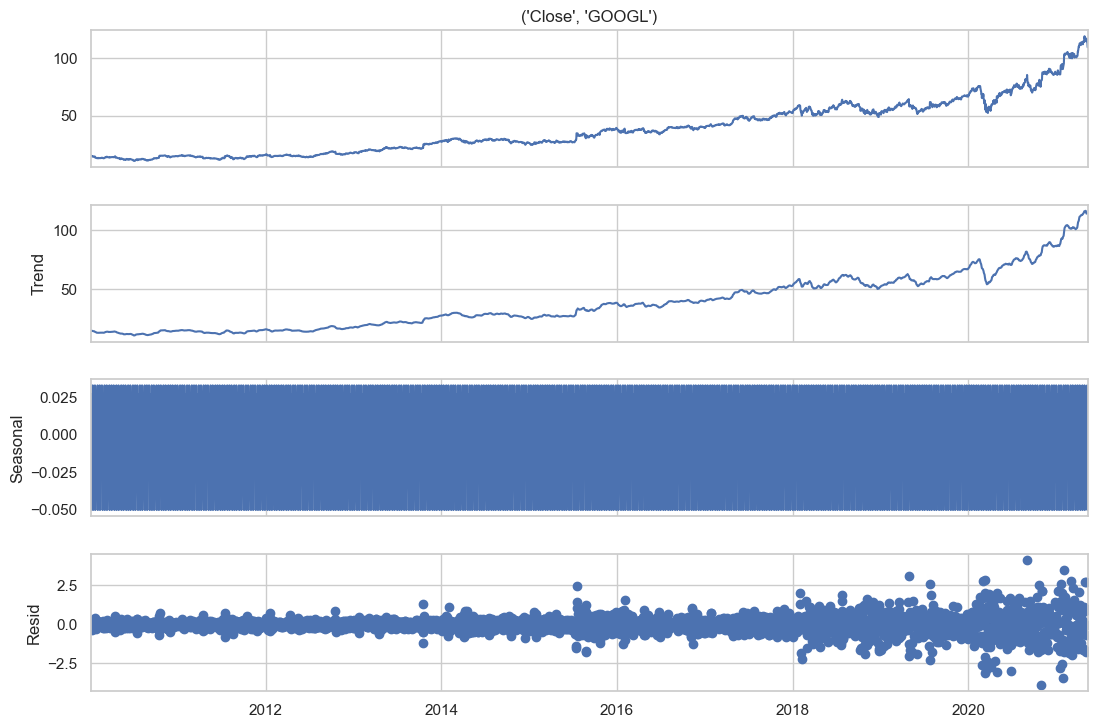

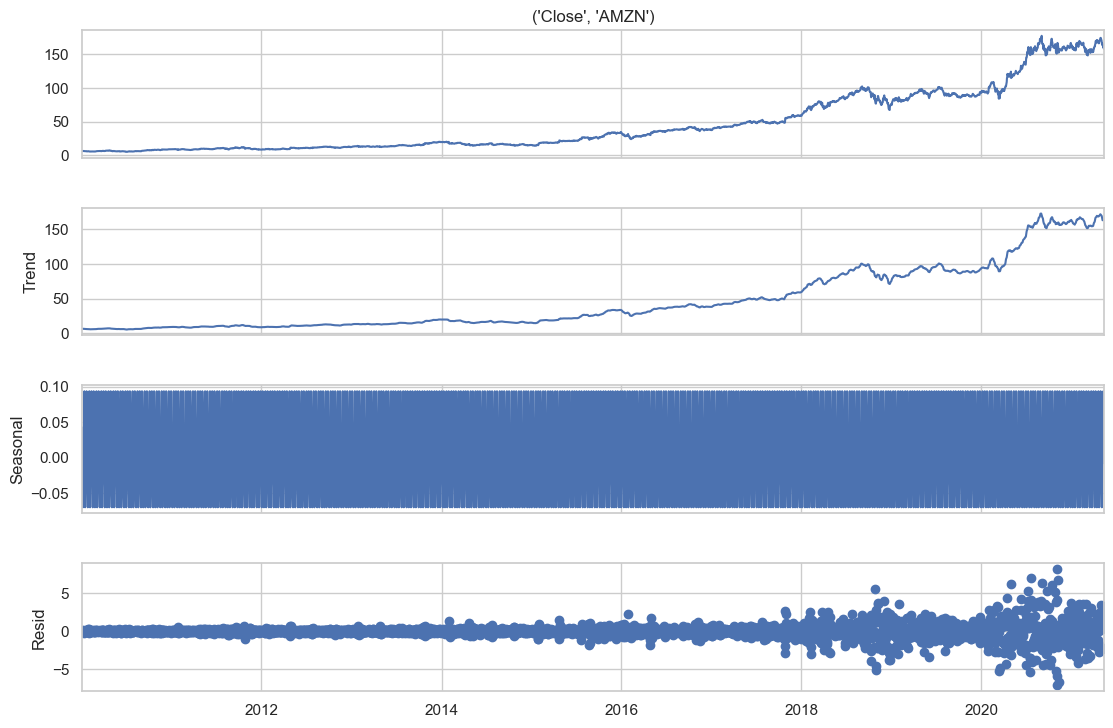

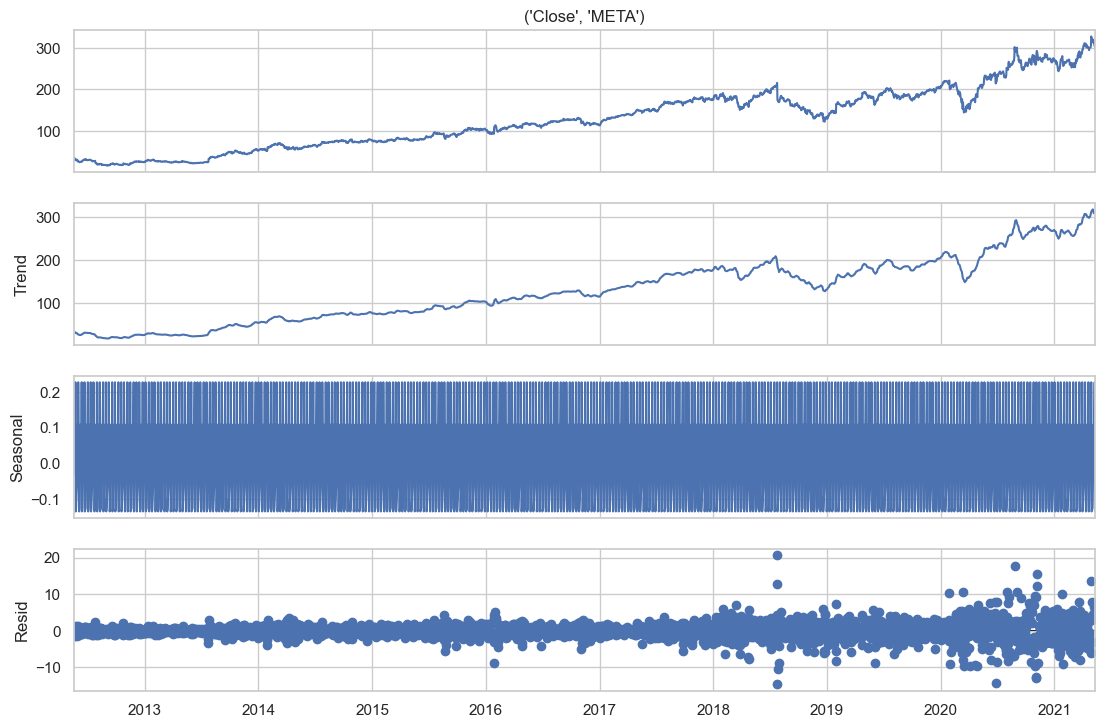

In [12]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

for ticker in tickers:
    stock_to_plot = ('Close', ticker) 
    series = train_df[stock_to_plot].dropna()

    series.index = pd.to_datetime(series.index)
    series = series.asfreq('B').ffill() 

    decomposition = seasonal_decompose(series, model='additive', period=7)

    fig = decomposition.plot()
    fig.set_size_inches(12, 8)
    plt.show()

Stocks have no seasonality, the pattern is just a mathematical noise, since the scale is very small comparing to the scale in the trend line.

Resampling Data

To better understand the trend of the data we will use the resampling method which provide a clearer view of trends and patterns when we are dealing with daily data.

Detecting Seasonality with Autocorrelation

We will detect Seasonality using the autocorrelation function (ACF) plot. Peaks at regular intervals in the ACF plot suggest the presence of seasonality.

<Figure size 1200x600 with 0 Axes>

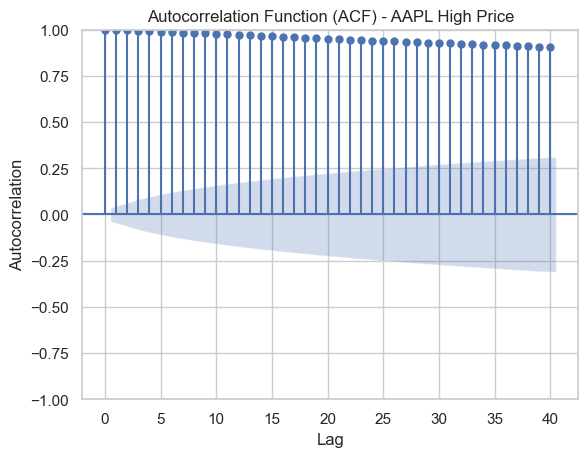

<Figure size 1200x600 with 0 Axes>

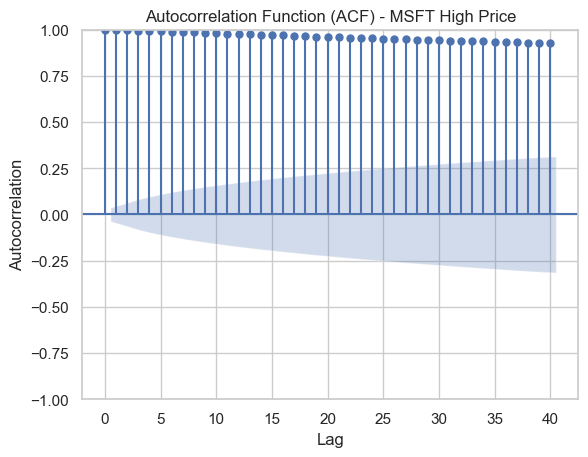

<Figure size 1200x600 with 0 Axes>

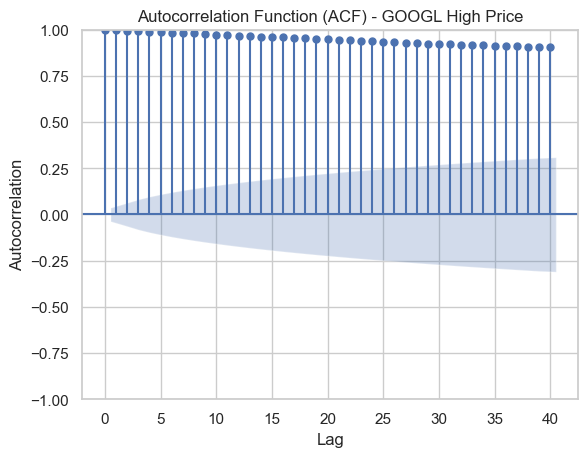

<Figure size 1200x600 with 0 Axes>

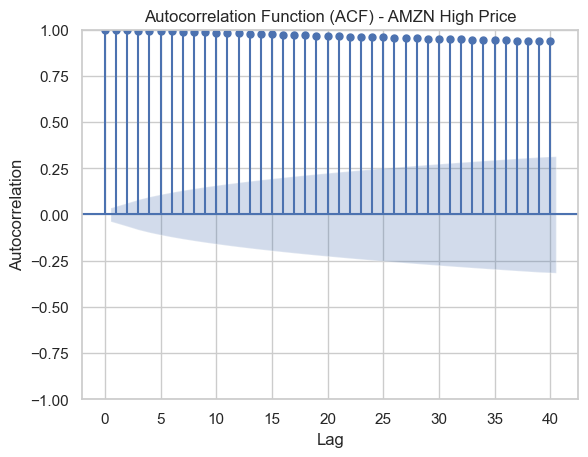

<Figure size 1200x600 with 0 Axes>

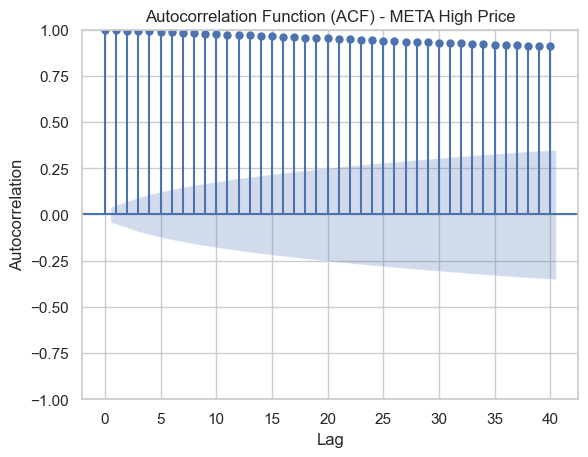

In [13]:
for ticker in tickers:    
    series_to_plot = train_df['High'][ticker].dropna()

    plt.figure(figsize=(12, 6))
    plot_acf(series_to_plot, lags=40)

    plt.xlabel('Lag')
    plt.ylabel('Autocorrelation')
    plt.title(f'Autocorrelation Function (ACF) - {ticker} High Price')
    plt.show()

The data is not stationary, we should not rely on seasonality for this raw stock data.

Testing Stationarity with ADF test

We will perform the ADF test to formally test for stationarity.

In [14]:
for ticker in tickers:
    series_to_plot = train_df['High'][ticker].dropna()

    result = adfuller(series_to_plot)

    print(f'ADF Test Results for {ticker} High')
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'   {key}: {value:.4f}')

    if result[1] <= 0.05:
        print("\nOutcome: The series is Stationary.\n")
    else:
        print("\nOutcome: The series is Non-Stationary (standard for raw stock prices).\n")

ADF Test Results for AAPL High
ADF Statistic: 1.7154
p-value: 0.9982
Critical Values:
   1%: -3.4327
   5%: -2.8626
   10%: -2.5673

Outcome: The series is Non-Stationary (standard for raw stock prices).

ADF Test Results for MSFT High
ADF Statistic: 5.1223
p-value: 1.0000
Critical Values:
   1%: -3.4327
   5%: -2.8626
   10%: -2.5673

Outcome: The series is Non-Stationary (standard for raw stock prices).

ADF Test Results for GOOGL High
ADF Statistic: 2.4763
p-value: 0.9990
Critical Values:
   1%: -3.4327
   5%: -2.8626
   10%: -2.5673

Outcome: The series is Non-Stationary (standard for raw stock prices).

ADF Test Results for AMZN High
ADF Statistic: 2.0124
p-value: 0.9987
Critical Values:
   1%: -3.4327
   5%: -2.8626
   10%: -2.5673

Outcome: The series is Non-Stationary (standard for raw stock prices).

ADF Test Results for META High
ADF Statistic: 0.3459
p-value: 0.9794
Critical Values:
   1%: -3.4333
   5%: -2.8628
   10%: -2.5675

Outcome: The series is Non-Stationary (standar

Based on the ADF Statistic we accept the null hypothesis, indicating that the data is not stationary according to the Augmented Dickey-Fuller test.
This suggests that differencing or other transformations may be needed to achieve stationarity before applying certain time series models.

Differencing to Achieve Stationarity

Differencing involves subtracting the previous observation from the current observation to remove trends or seasonality. 

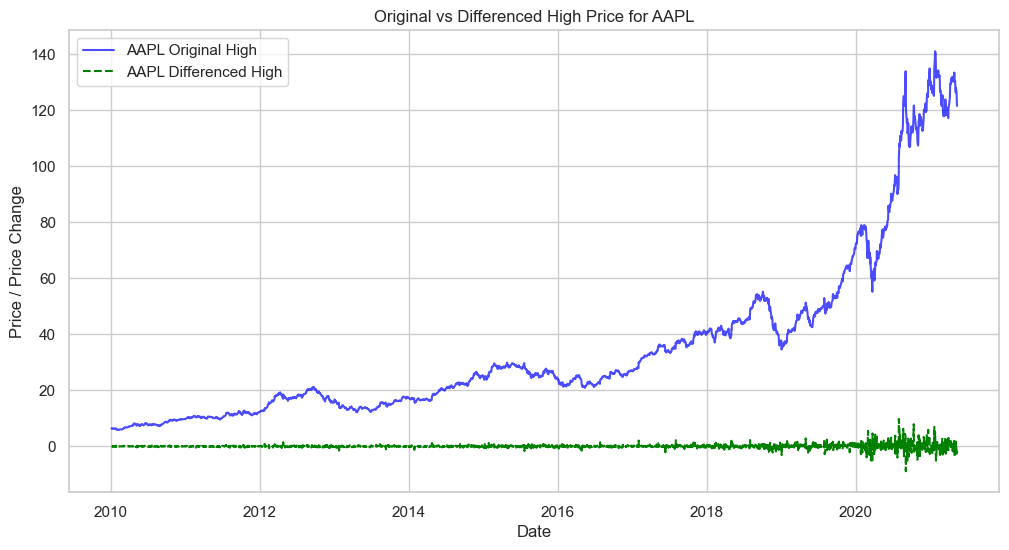

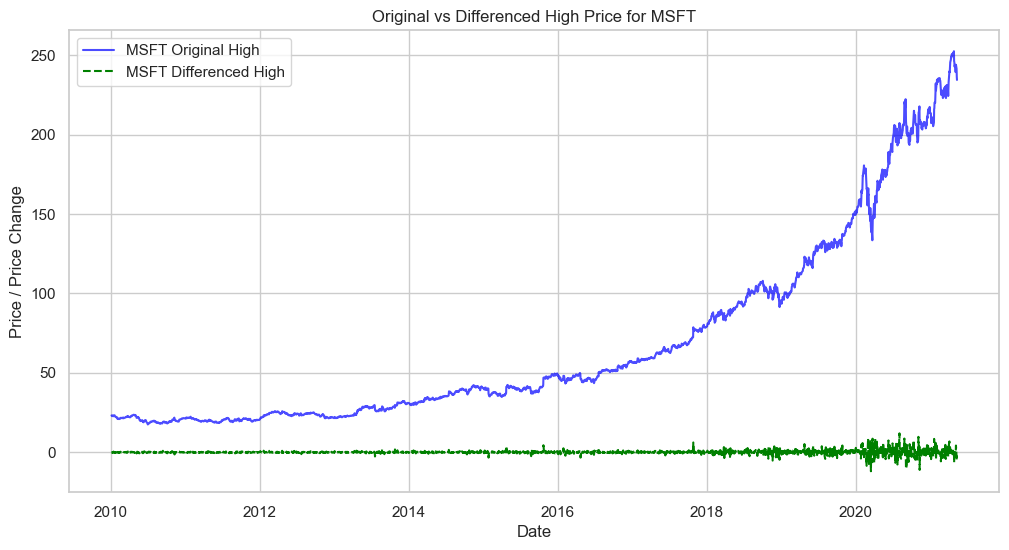

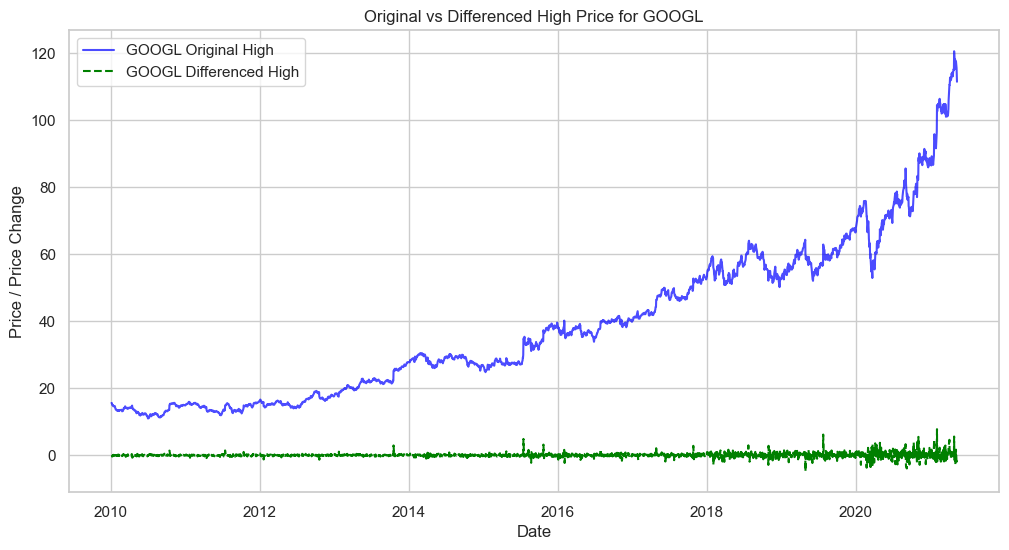

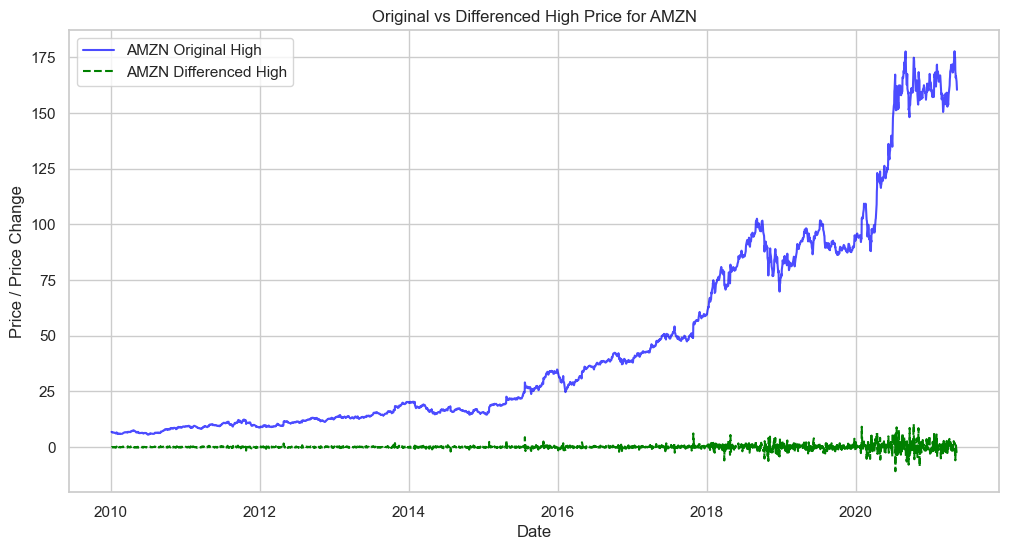

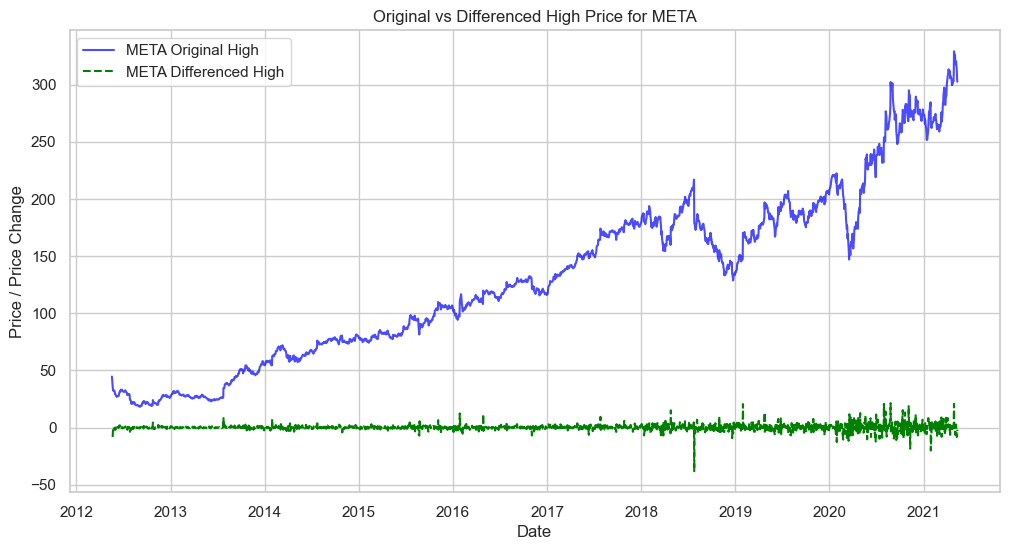

In [15]:
for ticker in tickers:
    train_df[('High_Diff', ticker)] = train_df[('High', ticker)].diff()
    
    original_high = train_df[('High', ticker)]
    differenced_high = train_df[('High_Diff', ticker)]

    plt.figure(figsize=(12, 6))
    plt.plot(original_high, label=f'{ticker} Original High', color='blue', alpha=0.7)
    plt.plot(differenced_high, label=f'{ticker} Differenced High', linestyle='--', color='green')

    plt.legend()
    plt.title(f'Original vs Differenced High Price for {ticker}')
    plt.xlabel('Date')
    plt.ylabel('Price / Price Change')
    plt.show()

Original Data vs. Differenced Data

In [16]:
cleaned_train_dfs = {}

for ticker in tickers:
    print(f"TICKER: {ticker}")

    temp_df = pd.DataFrame({
        'Original_High': train_df['High'][ticker],
        'High_Diff': train_df['High'][ticker].diff(),
        'Volume': train_df['Volume'][ticker]
    }).copy()

    temp_df.dropna(subset=['High_Diff'], inplace=True)
    
    cleaned_train_dfs[ticker] = temp_df

    result = adfuller(temp_df['High_Diff'])
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    
    if result[1] <= 0.05:
        print("Result: Stationary (Ready for modeling)\n")
    else:
        print("Result: Non-Stationary (Needs further differencing)\n")

TICKER: AAPL
ADF Statistic: -10.4551
p-value: 0.0000
Result: Stationary (Ready for modeling)

TICKER: MSFT
ADF Statistic: -13.8919
p-value: 0.0000
Result: Stationary (Ready for modeling)

TICKER: GOOGL
ADF Statistic: -11.5973
p-value: 0.0000
Result: Stationary (Ready for modeling)

TICKER: AMZN
ADF Statistic: -11.5161
p-value: 0.0000
Result: Stationary (Ready for modeling)

TICKER: META
ADF Statistic: -9.7374
p-value: 0.0000
Result: Stationary (Ready for modeling)



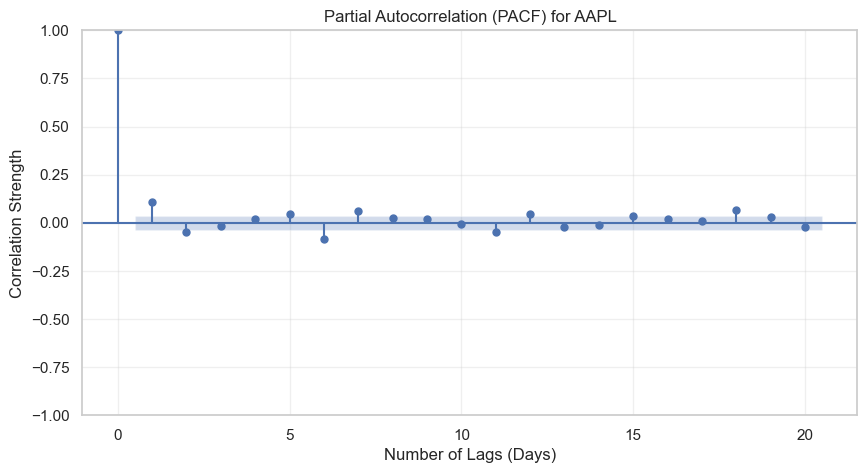

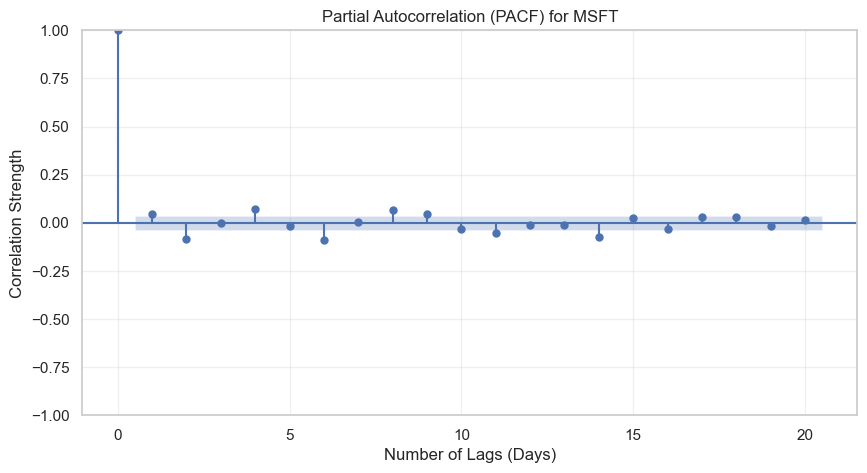

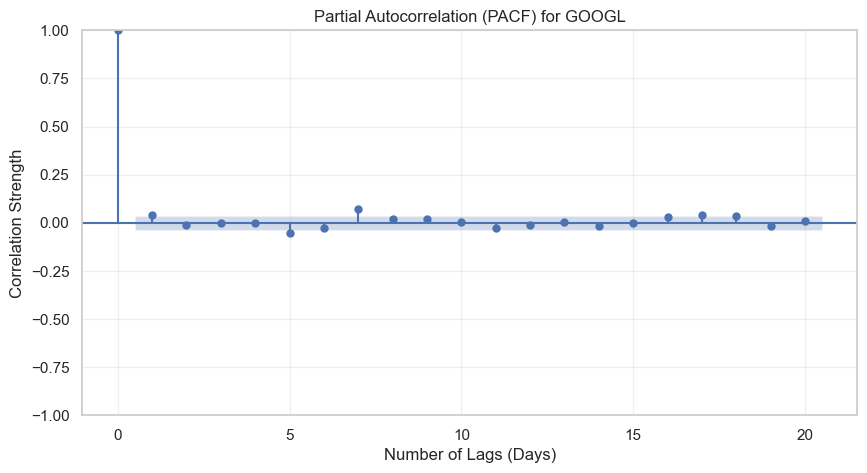

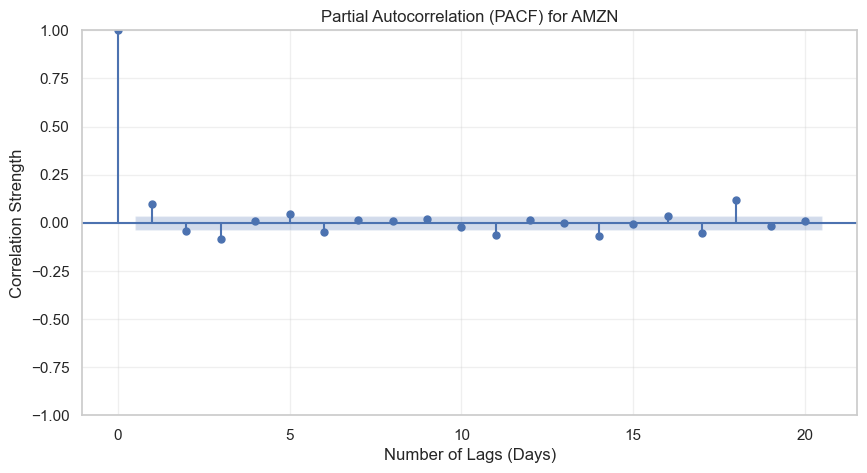

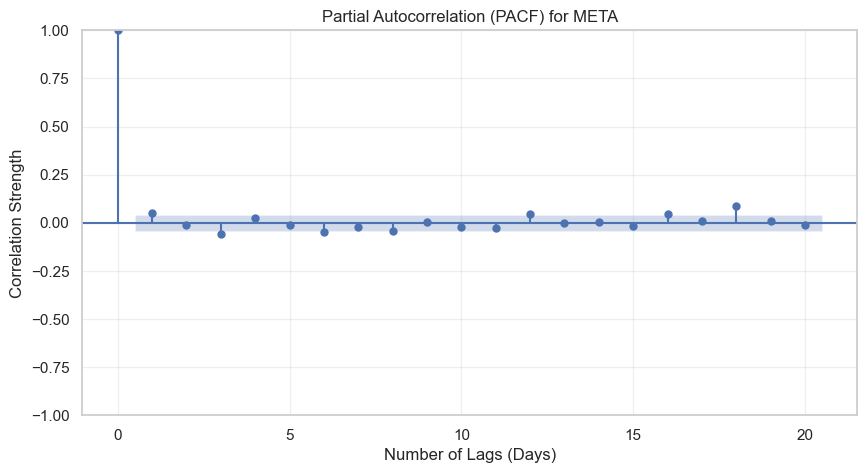

In [17]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_pacf

for ticker in tickers:
    df_stock = cleaned_train_dfs[ticker]

    series_to_check = df_stock['High_Diff'].dropna()

    fig, ax = plt.subplots(figsize=(10, 5))

    plot_pacf(series_to_check, lags=20, ax=ax, method='ywm')

    plt.title(f'Partial Autocorrelation (PACF) for {ticker}')
    plt.xlabel('Number of Lags (Days)')
    plt.ylabel('Correlation Strength')
    plt.grid(True, alpha=0.3)
    plt.show()

The best number of lags:
6 - aapl
2/4/6/8 - msft
7 - googl
1/3 - amzn
3/18 - meta

I will choose 7 days lag.

Based on the ADF Statistic we reject the null hypothesis and conclude that we have enough evidence to reject the null hypothesis

# Time series forecasting

In [18]:
all_train_data = []

for ticker, df in cleaned_train_dfs.items():
    df = df.copy()
    df['Ticker'] = ticker

    df['Vol_7d'] = df['High_Diff'].rolling(window=7).std()
    
    df['SMA_20'] = df['Original_High'].rolling(window=20).mean()
    df['Dist_SMA_20'] = (df['Original_High'] / df['SMA_20']) - 1
    
    delta = df['High_Diff']
    up = delta.clip(lower=0).rolling(window=14).mean()
    down = -delta.clip(upper=0).rolling(window=14).mean()

    rs = up / down.replace(0, np.nan) 
    df['RSI'] = 100 - (100 / (1 + rs))
    df['RSI'] = df['RSI'].fillna(50)

    df['Vol_Mean_20'] = df['Volume'].rolling(window=20).mean()
    df['Vol_Std_20'] = df['Volume'].rolling(window=20).std()
    df['Vol_ZScore'] = (df['Volume'] - df['Vol_Mean_20']) / df['Vol_Std_20']

    ema_12 = df['Original_High'].ewm(span=12, adjust=False).mean()
    ema_26 = df['Original_High'].ewm(span=26, adjust=False).mean()
    df['MACD'] = ema_12 - ema_26

    df['Upper_BB'] = df['SMA_20'] + (2 * df['Vol_7d'])
    df['Lower_BB'] = df['SMA_20'] - (2 * df['Vol_7d'])
    df['BB_Percent'] = (df['Original_High'] - df['Lower_BB']) / (df['Upper_BB'] - df['Lower_BB'])

    for lag in range(1, 8):
        df[f'lag_{lag}'] = df['High_Diff'].shift(lag)
    
    df['Target'] = df['High_Diff'].shift(-1)
    
    all_train_data.append(df)

master_train_df = pd.concat(all_train_data)

master_train_df.dropna(inplace=True)

daily_market_avg = master_train_df.groupby(level=0)['High_Diff'].transform('mean')

master_train_df['Relative_Performance'] = master_train_df['High_Diff'] - daily_market_avg

print(f"Master DF Shape: {master_train_df.shape}")
print(master_train_df[['Ticker', 'Vol_7d', 'RSI', 'Target']].head())

Master DF Shape: (13591, 24)
           Ticker    Vol_7d        RSI    Target
Date                                            
2010-02-02   AAPL  0.152879  34.924788  0.116258
2010-02-03   AAPL  0.163372  38.664651 -0.054832
2010-02-04   AAPL  0.102213  37.584719 -0.071013
2010-02-05   AAPL  0.101529  34.374953  0.056333
2010-02-08   AAPL  0.101383  32.047268 -0.011387


In [19]:
lag_features = [f'lag_{i}' for i in range(1, 8)]
tech_indicators = ['Vol_7d', 'Dist_SMA_20', 'RSI', 'Vol_ZScore', 'MACD', 'BB_Percent', 'Relative_Performance']
categorical_features = ['Ticker']

all_features = categorical_features + lag_features + tech_indicators

X_train = master_train_df[all_features]
y_train = master_train_df['Target']

print(f"Features being used: {X_train.columns.tolist()}")

Features being used: ['Ticker', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'Vol_7d', 'Dist_SMA_20', 'RSI', 'Vol_ZScore', 'MACD', 'BB_Percent', 'Relative_Performance']


Cleaning the validation dataset.

In [28]:
cleaned_val_dfs = {}

for ticker in tickers:
    temp_df = pd.DataFrame({
        'Original_High': val_df['High'][ticker],
        'High_Diff': val_df['High'][ticker].diff(),
        'Volume': val_df['Volume'][ticker]
    }).copy()

    temp_df.dropna(subset=['High_Diff'], inplace=True)
    
    cleaned_val_dfs[ticker] = temp_df

In [29]:
all_val_data = []

for ticker, df in cleaned_val_dfs.items():
    df = df.copy()
    df['Ticker'] = ticker

    df['Vol_7d'] = df['High_Diff'].rolling(window=7).std()
    
    df['SMA_20'] = df['Original_High'].rolling(window=20).mean()
    df['Dist_SMA_20'] = (df['Original_High'] / df['SMA_20']) - 1
    
    delta = df['High_Diff']
    up = delta.clip(lower=0).rolling(window=14).mean()
    down = -delta.clip(upper=0).rolling(window=14).mean()

    rs = up / down.replace(0, np.nan) 
    df['RSI'] = 100 - (100 / (1 + rs))
    df['RSI'] = df['RSI'].fillna(50)

    df['Vol_Mean_20'] = df['Volume'].rolling(window=20).mean()
    df['Vol_Std_20'] = df['Volume'].rolling(window=20).std()
    df['Vol_ZScore'] = (df['Volume'] - df['Vol_Mean_20']) / df['Vol_Std_20']

    ema_12 = df['Original_High'].ewm(span=12, adjust=False).mean()
    ema_26 = df['Original_High'].ewm(span=26, adjust=False).mean()
    df['MACD'] = ema_12 - ema_26

    df['Upper_BB'] = df['SMA_20'] + (2 * df['Vol_7d'])
    df['Lower_BB'] = df['SMA_20'] - (2 * df['Vol_7d'])
    df['BB_Percent'] = (df['Original_High'] - df['Lower_BB']) / (df['Upper_BB'] - df['Lower_BB'])

    for lag in range(1, 8):
        df[f'lag_{lag}'] = df['High_Diff'].shift(lag)
    
    df['Target'] = df['High_Diff'].shift(-1)
    
    all_val_data.append(df)

master_val_df = pd.concat(all_val_data)

master_val_df.dropna(inplace=True)

daily_market_avg = master_val_df.groupby(level=0)['High_Diff'].transform('mean')

master_val_df['Relative_Performance'] = master_val_df['High_Diff'] - daily_market_avg

print(f"Master DF Shape: {master_val_df.shape}")
print(master_val_df[['Ticker', 'Vol_7d', 'RSI', 'Target']].head())

Master DF Shape: (2960, 24)
           Ticker    Vol_7d        RSI    Target
Date                                            
2021-06-11   AAPL  1.056991  47.177488  3.024473
2021-06-14   AAPL  1.411949  60.030734  0.058559
2021-06-15   AAPL  1.417354  59.018891  0.282953
2021-06-16   AAPL  1.411250  64.583324  1.619592
2021-06-17   AAPL  1.340324  68.307222 -1.014737


In [30]:
X_val = master_val_df[all_features]
y_val = master_val_df['Target']

print(f"Features being used: {X_train.columns.tolist()}")

Features being used: ['Ticker', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'Vol_7d', 'Dist_SMA_20', 'RSI', 'Vol_ZScore', 'MACD', 'BB_Percent', 'Relative_Performance']


In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

numeric_features = [
    'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 
    'Vol_7d', 'Dist_SMA_20', 'RSI', 'Vol_ZScore', 'MACD', 
    'BB_Percent', 'Relative_Performance'
]
categorical_features = ['Ticker']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        
        ('num', StandardScaler(), numeric_features)
    ],
    remainder='drop' 
)

global_model = Pipeline([
    ('prep', preprocessor),
    ('regressor', Ridge(alpha=471.06, solver='cholesky', random_state=42))
])

In [32]:
models_to_test = {
    "Ridge": Ridge(alpha=1.0),
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, learning_rate=0.05, random_state=42),
    "KNN": KNeighborsRegressor(n_neighbors=5),
    "LightGBM": LGBMRegressor(n_estimators=100, learning_rate=0.05, random_state=42, verbose=-1),
    "CatBoost": CatBoostRegressor(n_estimators=100, learning_rate=0.05, silent=True, random_state=42)
}

results = []

for name, model in models_to_test.items():
    global_model.set_params(regressor=model)
    
    global_model.fit(X_train, y_train)
    
    for ticker in tickers:
        mask = X_val['Ticker'] == ticker
        
        if mask.any():
            preds = global_model.predict(X_val[mask])
            
            actuals = y_val[mask]
            mae = np.mean(np.abs(preds - actuals))
            
            results.append({
                'Model': name,
                'Ticker': ticker,
                'MAE': mae
            })
        else:
            print(f"Warning: No data found in X_val for ticker {ticker}")

comparison_df = pd.DataFrame(results)

c:\Users\Marta\miniconda3\envs\data-science\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Marta\miniconda3\envs\data-science\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Marta\miniconda3\envs\data-science\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Marta\miniconda3\envs\data-science\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Marta\miniconda3\envs\data-science\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRe

In [33]:
ranking_avg = comparison_df.groupby('Model')['MAE'].mean().sort_values()

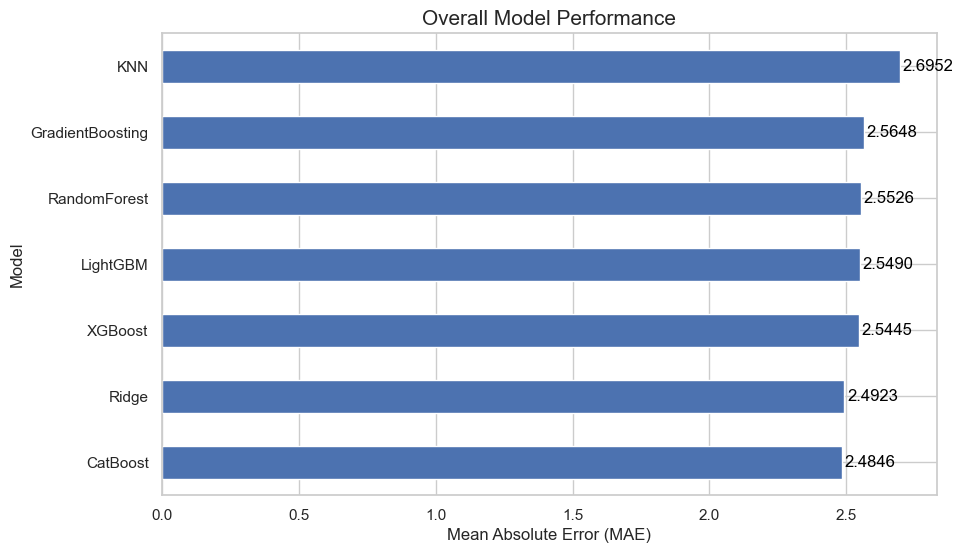

In [34]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

ax = ranking_avg.plot(kind='barh')

plt.title('Overall Model Performance', fontsize=15)
plt.xlabel('Mean Absolute Error (MAE)', fontsize=12)
plt.ylabel('Model', fontsize=12)

for i, v in enumerate(ranking_avg):
    ax.text(v + 0.01, i, f"{v:.4f}", color='black', va='center')

plt.show()

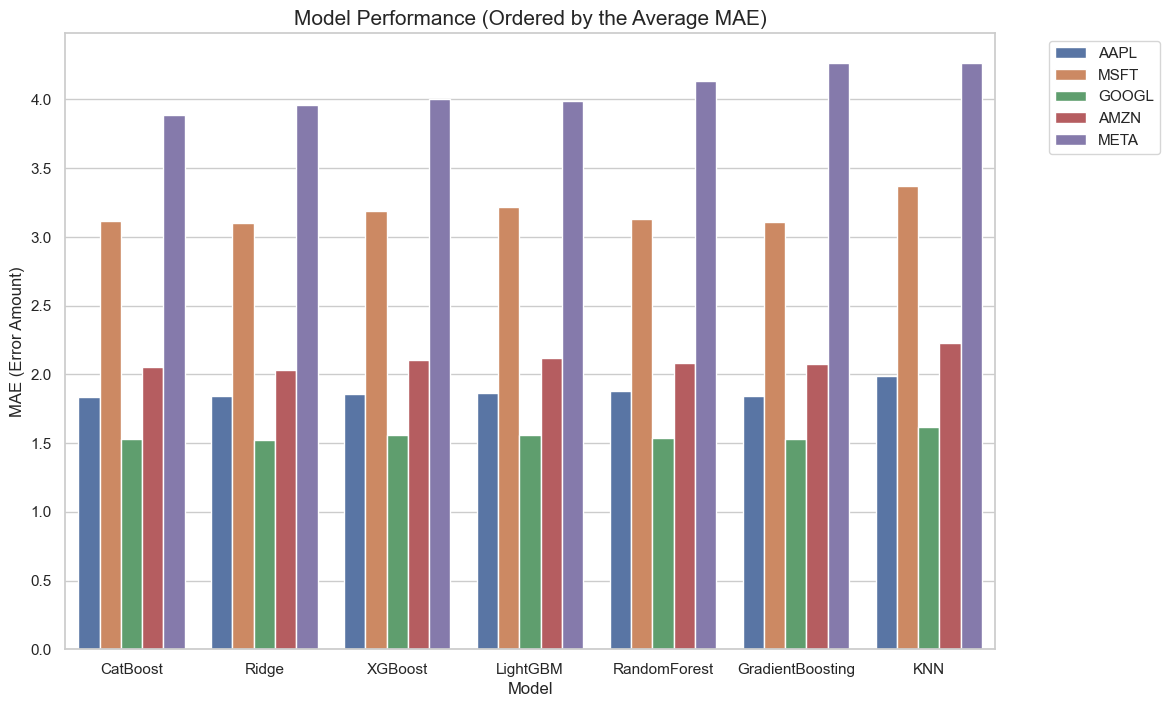

In [35]:
model_order = ranking_avg.index.tolist()

plt.figure(figsize=(12, 8))

sns.barplot(data=comparison_df, x='Model', y='MAE', hue='Ticker', order=model_order)

plt.title('Model Performance (Ordered by the Average MAE)', fontsize=15)
plt.ylabel('MAE (Error Amount)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

Ridge regression performed the best.

In [36]:
baseline_results = {}

for ticker in tickers:
    actuals = cleaned_val_dfs[ticker]['High_Diff']
    naive_preds = actuals.shift(1)
    
    valid_indices = naive_preds.dropna().index
    y_true = actuals.loc[valid_indices]
    y_naive = naive_preds.loc[valid_indices]
    
    baseline_mae = np.mean(np.abs(y_true - y_naive))
    baseline_results[ticker] = baseline_mae

    print(f"{ticker} Baseline MAE: {baseline_mae:.4f}")

AAPL Baseline MAE: 2.4406
MSFT Baseline MAE: 4.1871
GOOGL Baseline MAE: 2.0745
AMZN Baseline MAE: 2.7213
META Baseline MAE: 5.4394


Comparing to the baseline model, all models perform better.

In [37]:
from sklearn.metrics import r2_score
import optuna

In [38]:
model_order

['CatBoost',
 'Ridge',
 'XGBoost',
 'LightGBM',
 'RandomForest',
 'GradientBoosting',
 'KNN']

In [39]:
from sklearn.metrics import mean_absolute_error

In [40]:
def objective(trial):
    regressor_name = trial.suggest_categorical(
        "model", ["Ridge", "CatBoost", "XGBoost"]
    )
    
    if regressor_name == "Ridge":
        model = Ridge(
            alpha=trial.suggest_float("ridge_alpha", 0.1, 1000.0, log=True),
            solver=trial.suggest_categorical("ridge_solver", ['auto', 'svd', 'cholesky', 'lsqr', 'sag']),
            random_state=42
        )

    elif regressor_name == "CatBoost":
        model = CatBoostRegressor(
            iterations=trial.suggest_int("cb_iterations", 100, 1000),
            learning_rate=trial.suggest_float("cb_learning_rate", 0.001, 0.1, log=True),
            depth=trial.suggest_int("cb_depth", 2, 10),
            l2_leaf_reg=trial.suggest_float("cb_l2_reg", 1.0, 20, log=True),
            subsample=trial.suggest_float("cb_subsample", 0.05, 1.0),
            random_strength=trial.suggest_float("cb_random_strength", 1e-9, 10, log=True),
            loss_function="MAE", 
            random_state=42,
            verbose=False
        )

    elif regressor_name == "XGBoost":
        model = XGBRegressor(
            n_estimators=trial.suggest_int("xgb_n_estimators", 100, 1000),
            learning_rate=trial.suggest_float("xgb_learning_rate", 0.001, 0.1, log=True),
            max_depth=trial.suggest_int("xgb_max_depth", 3, 12),
            subsample=trial.suggest_float("xgb_subsample", 0.5, 1.0),
            min_child_weight=trial.suggest_int("xgb_min_child_weight", 1, 40),
            objective='reg:absoluteerror', 
            tree_method='hist',
            random_state=42,
            n_jobs=-1
        )

    pipeline = Pipeline([('prep', preprocessor), ('reg', model)])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_val)

    mae = mean_absolute_error(y_val, y_pred)
    
    return mae

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)

print(f"Best Model: {study.best_params['model']}")
print(f"Best MAE: {study.best_value}")

[I 2026-05-10 18:01:34,954] A new study created in memory with name: no-name-43cf5c32-16ac-4955-ad56-eb9ef7f1b689
[I 2026-05-10 18:01:41,367] Trial 0 finished with value: 2.5072364581332067 and parameters: {'model': 'XGBoost', 'xgb_n_estimators': 836, 'xgb_learning_rate': 0.05276609913814655, 'xgb_max_depth': 9, 'xgb_subsample': 0.8296733449241855, 'xgb_min_child_weight': 33}. Best is trial 0 with value: 2.5072364581332067.
[I 2026-05-10 18:01:41,440] Trial 1 finished with value: 2.4922537833287666 and parameters: {'model': 'Ridge', 'ridge_alpha': 0.438759956198974, 'ridge_solver': 'svd'}. Best is trial 1 with value: 2.4922537833287666.
[I 2026-05-10 18:01:44,319] Trial 2 finished with value: 2.476338522747983 and parameters: {'model': 'CatBoost', 'cb_iterations': 840, 'cb_learning_rate': 0.00484319425515261, 'cb_depth': 3, 'cb_l2_reg': 1.0709242819255271, 'cb_subsample': 0.7346380064087727, 'cb_random_strength': 8.5320275151816e-08}. Best is trial 2 with value: 2.476338522747983.
[I 2

Best Model: XGBoost
Best MAE: 2.46726730046173


In [41]:
def get_best_params_for_model(study, model_name):
    model_trials = [
        t for t in study.trials 
        if t.params.get("model") == model_name and t.state == optuna.trial.TrialState.COMPLETE
    ]
    
    if not model_trials:
        return f"No trials found for {model_name}"
    
    best_model_trial = min(model_trials, key=lambda t: t.value)
    
    return {
        "params": best_model_trial.params,
        "mae": best_model_trial.value
    }

ridge_best = get_best_params_for_model(study, "Ridge")
cat_best = get_best_params_for_model(study, "CatBoost")
xgb_best = get_best_params_for_model(study, "XGBoost")

print("Best Ridge Parameters:", ridge_best['params'])
print("Best CatBoost Parameters:", cat_best['params'])
print("Best GradientBoosting Parameters:", xgb_best['params'])

Best Ridge Parameters: {'model': 'Ridge', 'ridge_alpha': 769.0022740277509, 'ridge_solver': 'cholesky'}
Best CatBoost Parameters: {'model': 'CatBoost', 'cb_iterations': 383, 'cb_learning_rate': 0.05241456711164146, 'cb_depth': 2, 'cb_l2_reg': 1.0487941549554132, 'cb_subsample': 0.28152493839782483, 'cb_random_strength': 1.998559411732539e-06}
Best GradientBoosting Parameters: {'model': 'XGBoost', 'xgb_n_estimators': 927, 'xgb_learning_rate': 0.006413664125276758, 'xgb_max_depth': 5, 'xgb_subsample': 0.7857264252337374, 'xgb_min_child_weight': 19}


In [42]:
model1 = Ridge(
    alpha=769.0022740277509, 
    solver='cholesky', 
    random_state=42
)

model2 = CatBoostRegressor(
    iterations=383, 
    learning_rate=0.05241456711164146, 
    depth=2, 
    l2_leaf_reg=1.0487941549554132, 
    subsample=0.28152493839782483, 
    random_strength=1.998559411732539e-06,
    loss_function='MAE', 
    verbose=False,
    random_state=42
)

model3 = XGBRegressor(
    n_estimators=927, 
    learning_rate=0.006413664125276758, 
    max_depth=5, 
    subsample=0.7857264252337374, 
    min_child_weight=19,
    objective='reg:absoluteerror',
    tree_method='hist',
    random_state=42
)

In [43]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor, VotingRegressor
from catboost import CatBoostRegressor
from sklearn.pipeline import Pipeline

ensemble = VotingRegressor(estimators=[
    ('ridge', model1),
    ('cat', model2),
    ('xgb', model3)
])

pipeline_ensemble_3 = Pipeline([('prep', preprocessor), ('reg', ensemble)])

pipeline_ensemble_3.fit(X_train, y_train)
y_pred_ensemble_3 = pipeline_ensemble_3.predict(X_val)

In [44]:
ensemble_3_mae = mean_absolute_error(y_val, y_pred_ensemble_3)

print(f"Ensemble Voting Regressor MAE: {ensemble_3_mae:.6f}")

Ensemble Voting Regressor MAE: 2.473010


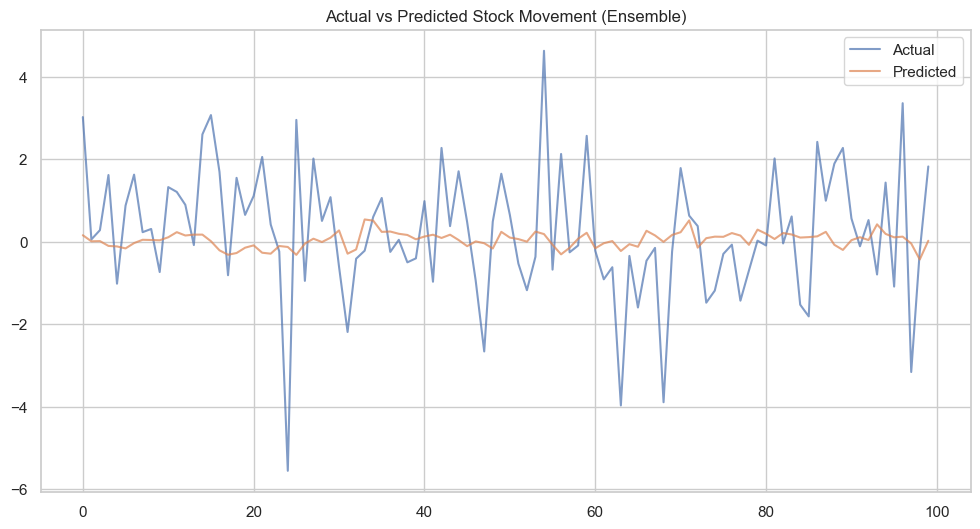

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(y_val.values[:100], label='Actual', alpha=0.7)
plt.plot(y_pred_ensemble_3[:100], label='Predicted', alpha=0.7)
plt.title('Actual vs Predicted Stock Movement (Ensemble)')
plt.legend()
plt.show()

In [46]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor, VotingRegressor
from catboost import CatBoostRegressor
from sklearn.pipeline import Pipeline

ensemble = VotingRegressor(estimators=[
    ('cat', model2),
    ('xgb', model3)
])

pipeline_ensemble_2 = Pipeline([('prep', preprocessor), ('reg', ensemble)])

pipeline_ensemble_2.fit(X_train, y_train)
y_pred_ensemble_2 = pipeline_ensemble_2.predict(X_val)

In [47]:
ensemble_2_mae = mean_absolute_error(y_val, y_pred_ensemble_2)

print(f"Ensemble Voting Regressor MAE: {ensemble_2_mae:.6f}")

Ensemble Voting Regressor MAE: 2.468203


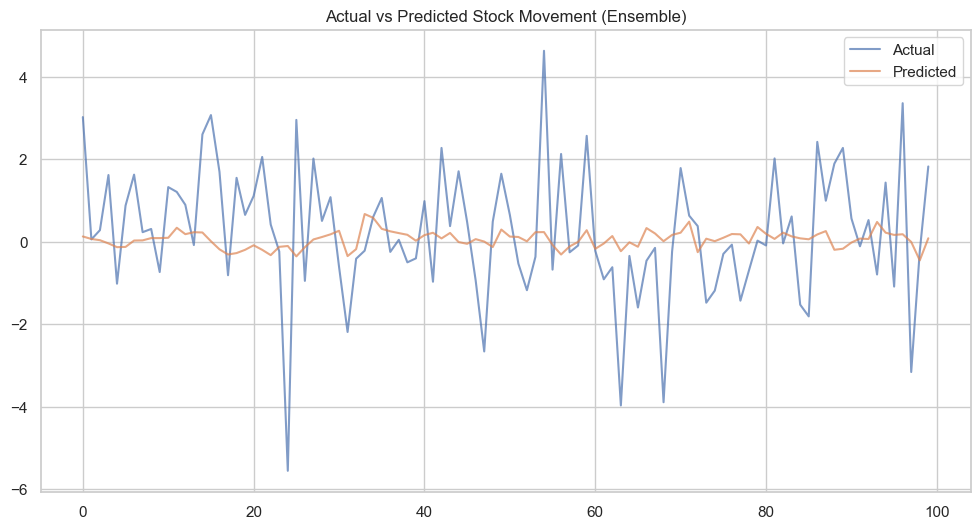

In [48]:
plt.figure(figsize=(12, 6))
plt.plot(y_val.values[:100], label='Actual', alpha=0.7)
plt.plot(y_pred_ensemble_2[:100], label='Predicted', alpha=0.7)
plt.title('Actual vs Predicted Stock Movement (Ensemble)')
plt.legend()
plt.show()

In [49]:
from sklearn.ensemble import StackingRegressor

stack_ensemble = StackingRegressor(
    estimators=[('cat', model2), ('xgb', model3)],
    final_estimator=Ridge()
)

pipeline_stack_ensemble = Pipeline([('prep', preprocessor), ('reg', stack_ensemble)])

pipeline_stack_ensemble.fit(X_train, y_train)
y_pred_stack_ensemble = pipeline_stack_ensemble.predict(X_val)

In [50]:
stack_ensemble_mae = mean_absolute_error(y_val, y_pred_stack_ensemble)

print(f"Ensemble Voting Regressor MAE: {stack_ensemble_mae:.6f}")

Ensemble Voting Regressor MAE: 2.473096


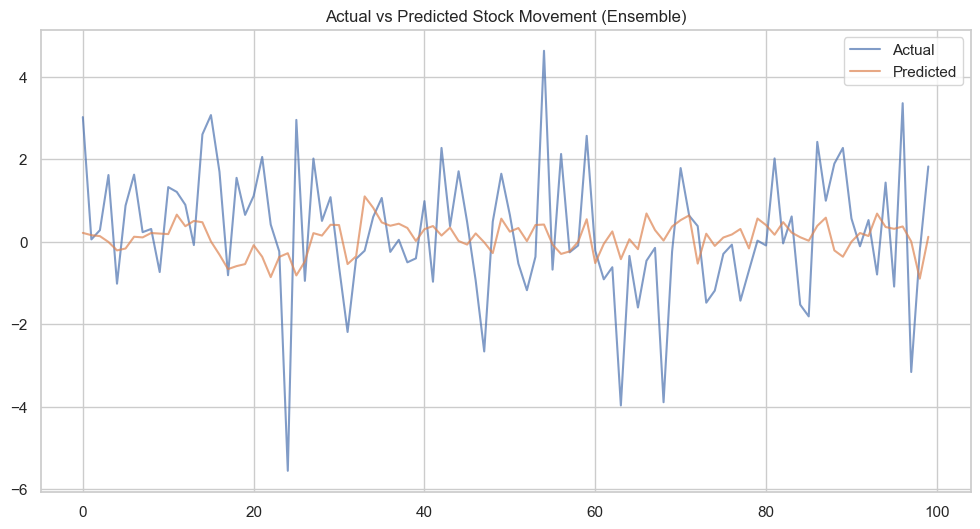

In [51]:
plt.figure(figsize=(12, 6))
plt.plot(y_val.values[:100], label='Actual', alpha=0.7)
plt.plot(y_pred_stack_ensemble[:100], label='Predicted', alpha=0.7)
plt.title('Actual vs Predicted Stock Movement (Ensemble)')
plt.legend()
plt.show()

best model so far.

# Survival analysis

# Ranking model